# Statistics for Machine Learning — Notebook 3  
# Probability Distributions for Machine Learning

## Why this notebook matters

In Machine Learning, data is not random chaos.

Many real-world features follow patterns called **probability distributions**.

Examples:

| Real-world data | Possible distribution |
|---|---|
| Customer churn yes/no | Bernoulli |
| Number of churned customers out of 100 | Binomial |
| Human height, measurement noise | Normal |
| Website visits per minute | Poisson |
| Time until next customer arrives | Exponential |
| Income, prices, spending | Log-normal |

If you understand distributions, you can understand:

- feature behavior
- outliers
- data simulation
- model assumptions
- likelihood
- uncertainty
- preprocessing decisions
- anomaly detection
- evaluation uncertainty

---

## What you will learn

1. What probability distributions are  
2. Discrete vs continuous distributions  
3. Probability mass function and probability density function  
4. Bernoulli distribution  
5. Binomial distribution  
6. Normal distribution  
7. Standard normal distribution  
8. Z-score and normal probability  
9. Poisson distribution  
10. Exponential distribution  
11. Log-normal distribution  
12. Sampling from distributions  
13. Comparing real data with distributions  
14. Why distributions matter in ML  
15. Mini project: identify distributions in a customer dataset

# 1. What is a probability distribution?

A probability distribution describes how likely different values are.

Example:

If we toss a coin:

```text
P(Heads) = 0.5
P(Tails) = 0.5
```

This is a distribution over two possible outcomes.

If we measure human height, there are many possible values, and most values are near the average.

That shape is also a distribution.

---

## In ML language

A feature column has a distribution.

Example:

```text
income
age
clicks
support_tickets
model_confidence
prediction_error
```

Before modeling, we should ask:

> What is the distribution of this feature?

# 2. Setup

Run this cell first.

If something is missing:

```python
!pip install numpy pandas matplotlib seaborn scipy scikit-learn ipywidgets
```

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    bernoulli,
    binom,
    norm,
    poisson,
    expon,
    lognorm
)

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Install it using: pip install ipywidgets")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


# 3. Discrete vs Continuous distributions

## Discrete distribution

A discrete variable has countable values.

Examples:

- coin toss: 0 or 1
- number of purchases
- number of support tickets
- number of fraud transactions
- number of emails received

## Continuous distribution

A continuous variable can take many decimal values.

Examples:

- height
- weight
- income
- time
- temperature
- model confidence score
- prediction error

---

## ML connection

| Feature type | Example | Distribution type |
|---|---|---|
| Binary target | churn yes/no | Discrete |
| Count feature | number of clicks | Discrete |
| Numeric measurement | age, height | Continuous |
| Time duration | time until next event | Continuous |

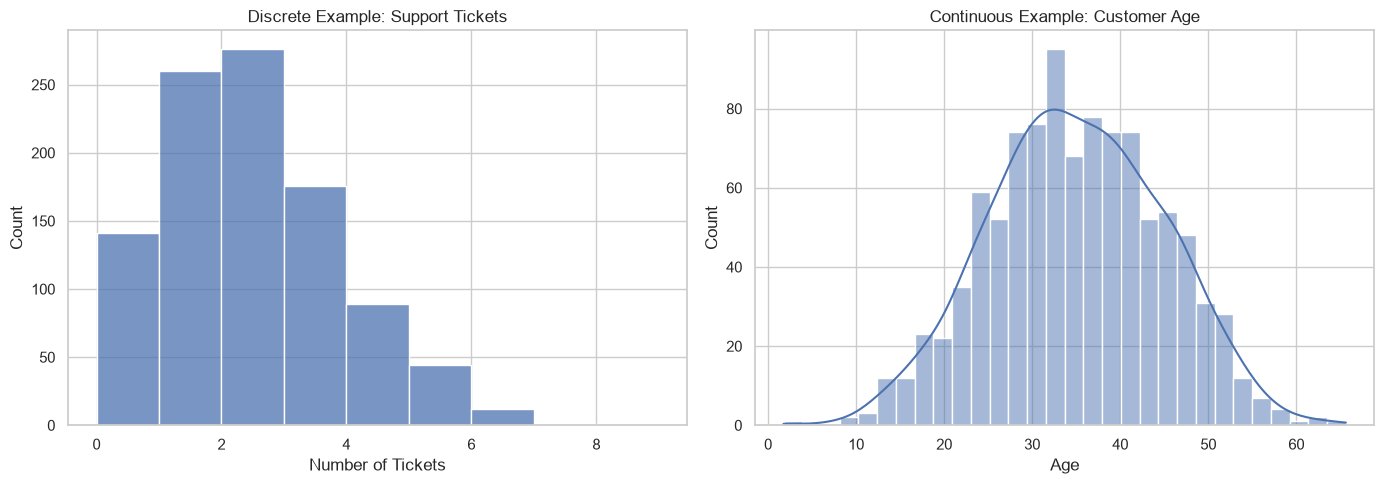

In [2]:
# Discrete example
support_tickets = np.random.poisson(lam=2, size=1000)

# Continuous example
customer_age = np.random.normal(loc=35, scale=10, size=1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(support_tickets, bins=range(0, support_tickets.max() + 2), ax=axes[0])
axes[0].set_title("Discrete Example: Support Tickets")
axes[0].set_xlabel("Number of Tickets")

sns.histplot(customer_age, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Continuous Example: Customer Age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

# 4. PMF vs PDF

## PMF — Probability Mass Function

Used for discrete variables.

It gives probability of exact values.

Example:

```text
P(X = 3)
```

Meaning:

> Probability that the count is exactly 3.

---

## PDF — Probability Density Function

Used for continuous variables.

For continuous variables, probability of one exact value is almost zero.

Instead, we calculate probability over intervals:

```text
P(30 < X < 40)
```

The PDF curve shows density, not direct probability at one point.

# 5. Bernoulli distribution

Bernoulli distribution models one trial with two possible outcomes:

```text
1 = success
0 = failure
```

Examples in ML:

- customer churns or not
- email is spam or not
- transaction is fraud or not
- user clicks ad or not
- model prediction correct or incorrect

Parameter:

```text
p = probability of success
```

Example:

If churn probability is 0.30:

```text
X ~ Bernoulli(0.30)
```

,outcome,probability
0,0,0.7
1,1,0.3
2,1,0.3


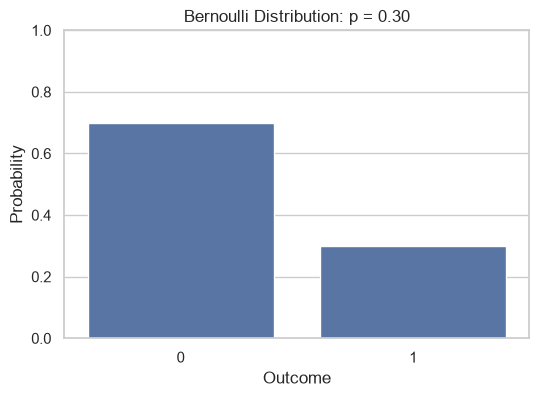

In [3]:
p = 0.30

x_values = [0, 1,1]
probabilities = bernoulli.pmf(x_values, p)

bernoulli_df = pd.DataFrame({
    "outcome": x_values,
    "probability": probabilities
})

display(bernoulli_df)

plt.figure(figsize=(6, 4))
sns.barplot(data=bernoulli_df, x="outcome", y="probability")
plt.title("Bernoulli Distribution: p = 0.30")
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.show()

array([0.3, 0.7])

# 6. Simulate Bernoulli trials

Now we simulate 1000 customers where:

```text
P(churn = 1) = 0.30
```

The average of Bernoulli samples should be close to p.

Expected churn probability: 0.3
Simulated churn rate: 0.302


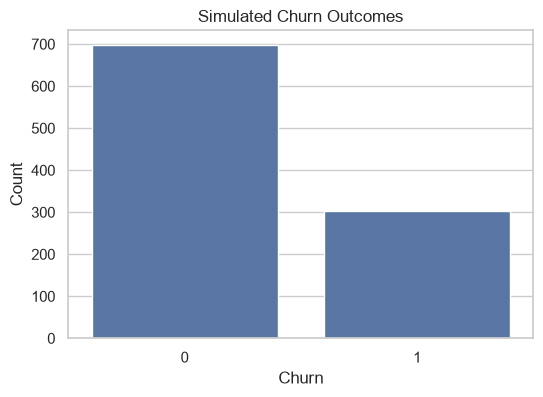

In [20]:
n = 1000
p_churn = 0.30

churn_samples = bernoulli.rvs(p_churn, size=n, random_state=42)

print("Expected churn probability:", p_churn)
print("Simulated churn rate:", churn_samples.mean().round(3))

plt.figure(figsize=(6, 4))
sns.countplot(x=churn_samples)
plt.title("Simulated Churn Outcomes")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# 7. Interactive Bernoulli distribution

Change probability `p` and see how the distribution changes.

In [4]:
def plot_bernoulli(p=0.5):
    x_values = [0, 1]
    probs = bernoulli.pmf(x_values, p)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=x_values, y=probs)
    plt.title(f"Bernoulli Distribution | p = {p:.2f}")
    plt.xlabel("Outcome")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.show()

    print(f"P(X=0): {1-p:.2f}")
    print(f"P(X=1): {p:.2f}")

if WIDGETS_AVAILABLE:
    interact(
        plot_bernoulli,
        p=widgets.FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01)
    )
else:
    plot_bernoulli(0.5)

interactive(children=(FloatSlider(value=0.5, description='p', max=0.99, min=0.01, step=0.01), Output()), _dom_…

# 8. Binomial distribution

Binomial distribution models the number of successes in multiple Bernoulli trials.

Example:

If 100 customers each have 30% probability of churn:

```text
X = number of customers who churn
X ~ Binomial(n=100, p=0.30)
```

Parameters:

- `n` = number of trials
- `p` = probability of success

Examples in ML:

- number of churned customers in a batch
- number of correct predictions out of 100
- number of clicked ads out of 1000 impressions
- number of fraud transactions in a day

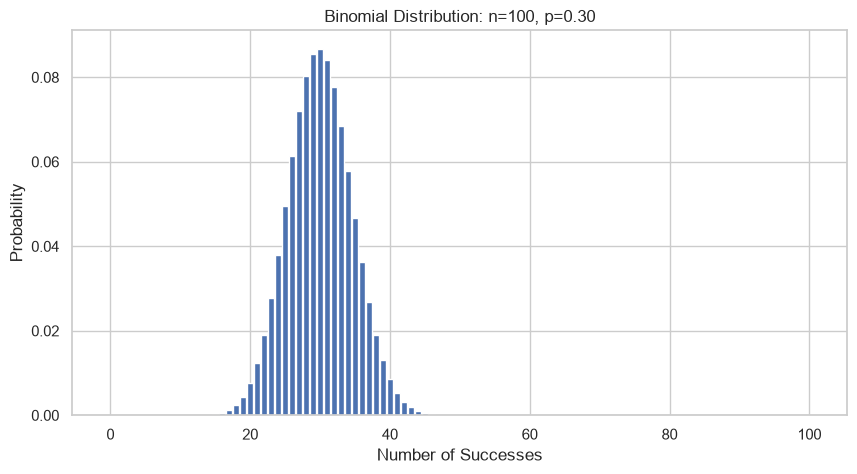

Expected value: 30.0
Standard deviation: 4.58


In [5]:
n_trials = 100
p_success = 0.30

x_values = np.arange(0, n_trials + 1)
pmf_values = binom.pmf(x_values, n_trials, p_success)

plt.figure(figsize=(10, 5))
plt.bar(x_values, pmf_values)
plt.title("Binomial Distribution: n=100, p=0.30")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.show()

print("Expected value:", n_trials * p_success)
print("Standard deviation:", np.sqrt(n_trials * p_success * (1 - p_success)).round(2))

# 9. Binomial probability questions

Example question:

> If 100 customers have 30% churn probability, what is probability that exactly 30 churn?

We calculate:

```python
binom.pmf(30, n=100, p=0.30)
```

Another question:

> What is probability that 40 or more customers churn?

We calculate:

```python
1 - binom.cdf(39, n=100, p=0.30)
```

In [6]:
prob_exact_30 = binom.pmf(30, n_trials, p_success)
prob_40_or_more = 1 - binom.cdf(39, n_trials, p_success)

print("P(exactly 30 churn):", round(prob_exact_30, 4))
print("P(40 or more churn):", round(prob_40_or_more, 4))

P(exactly 30 churn): 0.0868
P(40 or more churn): 0.021


# 10. Interactive Binomial distribution

Change `n` and `p`.

Notice:

- larger `n` makes the distribution wider in count values
- higher `p` shifts distribution to the right
- p close to 0.5 makes distribution more symmetric

In [7]:
def plot_binomial(n=50, p=0.3):
    x = np.arange(0, n + 1)
    y = binom.pmf(x, n, p)

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Binomial Distribution | n={n}, p={p:.2f}")
    plt.xlabel("Number of Successes")
    plt.ylabel("Probability")
    plt.show()

    print("Expected value:", round(n * p, 2))
    print("Standard deviation:", round(np.sqrt(n * p * (1 - p)), 2))

if WIDGETS_AVAILABLE:
    interact(
        plot_binomial,
        n=widgets.IntSlider(value=50, min=5, max=200, step=5),
        p=widgets.FloatSlider(value=0.3, min=0.01, max=0.99, step=0.01)
    )
else:
    plot_binomial(50, 0.3)

interactive(children=(IntSlider(value=50, description='n', max=200, min=5, step=5), FloatSlider(value=0.3, des…

# 11. Normal distribution

Normal distribution is the famous bell curve.

It is common in:

- measurement noise
- height
- test scores
- model errors in some cases
- averaged quantities

Parameters:

- `mean` controls center
- `standard deviation` controls spread

Notation:

```text
X ~ Normal(mean, standard deviation)
```

Example:

```text
height ~ Normal(170, 10)
```

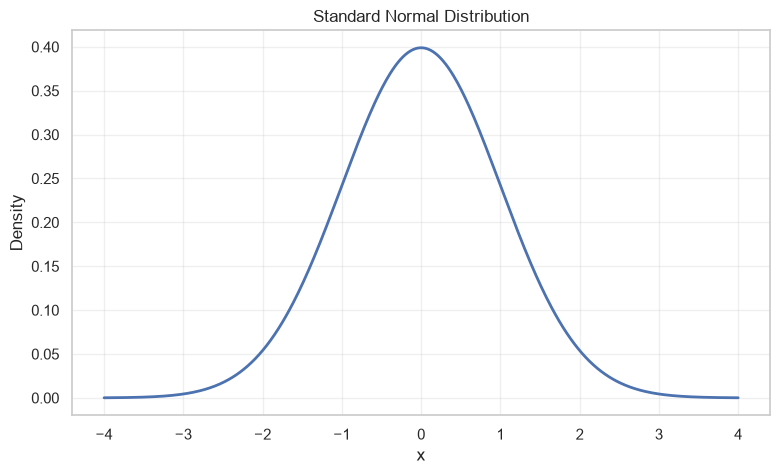

In [8]:
mu = 0
sigma = 1

x = np.linspace(-4, 4, 500)
y = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(9, 5))
plt.plot(x, y, linewidth=2)
plt.title("Standard Normal Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

# 12. Normal distribution with different standard deviations

The mean controls center.

The standard deviation controls spread.

Small standard deviation:
- narrow curve
- values close to mean

Large standard deviation:
- wide curve
- values more spread out

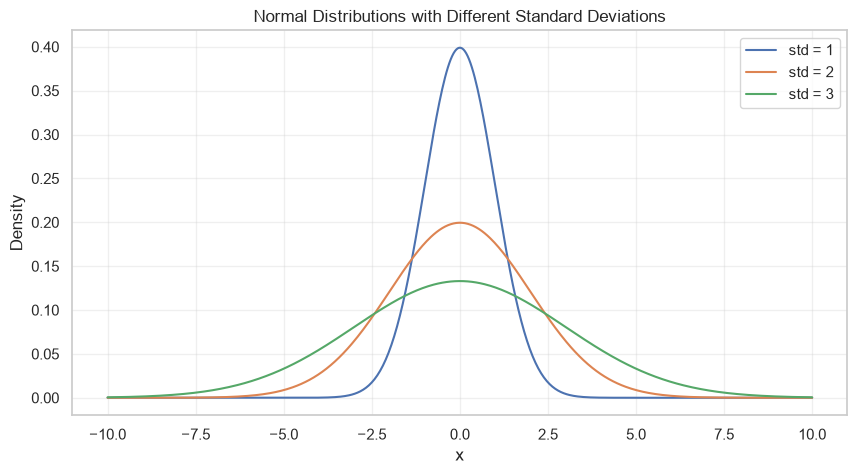

In [10]:
x = np.linspace(-10, 10, 500)

plt.figure(figsize=(10, 5))

for sigma in [1, 2, 3]:
    y = norm.pdf(x, loc=0, scale=sigma)
    plt.plot(x, y, label=f"std = {sigma}")

plt.title("Normal Distributions with Different Standard Deviations")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13. Normal distribution probability

For continuous distributions, we calculate probability over intervals.

Example:

If exam scores follow:

```text
X ~ Normal(70, 10)
```

What is probability score is above 85?

```python
1 - norm.cdf(85, loc=70, scale=10)
```

In [11]:
mean_score = 70
std_score = 10

prob_above_85 = 1 - norm.cdf(85, loc=mean_score, scale=std_score)
prob_between_60_80 = norm.cdf(80, loc=mean_score, scale=std_score) - norm.cdf(60, loc=mean_score, scale=std_score)

print("P(score > 85):", round(prob_above_85, 4))
print("P(60 < score < 80):", round(prob_between_60_80, 4))

P(score > 85): 0.0668
P(60 < score < 80): 0.6827


# 14. The 68-95-99.7 rule

For a normal distribution:

- about 68% of data is within 1 standard deviation
- about 95% is within 2 standard deviations
- about 99.7% is within 3 standard deviations

This helps detect unusual values.

If a value is more than 3 standard deviations from the mean, it may be an outlier.

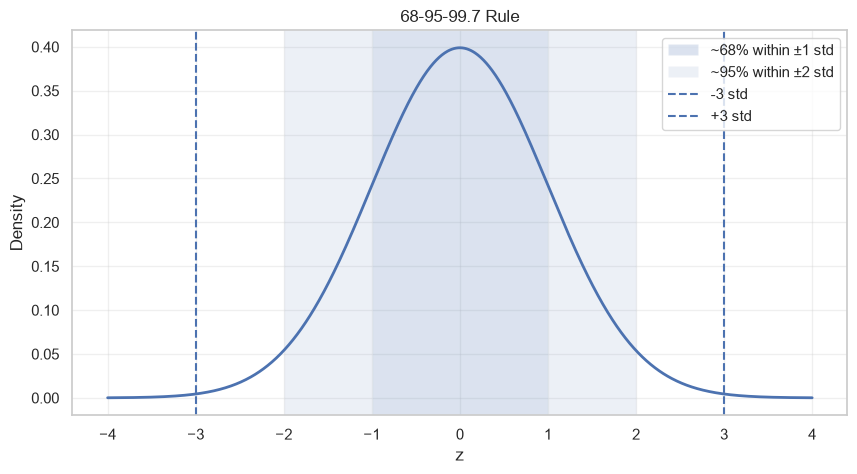

In [12]:
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, linewidth=2)

plt.axvspan(-1, 1, alpha=0.2, label="~68% within ±1 std")
plt.axvspan(-2, -1, alpha=0.1)
plt.axvspan(1, 2, alpha=0.1, label="~95% within ±2 std")
plt.axvline(-3, linestyle="--", label="-3 std")
plt.axvline(3, linestyle="--", label="+3 std")

plt.title("68-95-99.7 Rule")
plt.xlabel("z")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 15. Standard normal distribution and z-score

Standard normal distribution has:

```text
mean = 0
standard deviation = 1
```

A z-score converts any normal value to standard normal scale:

```text
z = (x - mean) / standard deviation
```

Why useful?

It tells how unusual a value is compared with the distribution.

In [13]:
x_value = 85
mean = 70
std = 10

z = (x_value - mean) / std

print("x:", x_value)
print("mean:", mean)
print("std:", std)
print("z-score:", z)

prob_above = 1 - norm.cdf(z)

print("P(Z > z):", round(prob_above, 4))

x: 85
mean: 70
std: 10
z-score: 1.5
P(Z > z): 0.0668


# 16. Interactive Normal distribution

Change mean and standard deviation.

Observe:

- mean shifts curve left/right
- standard deviation controls width

In [14]:
def plot_normal(mean=0, std=1):
    x = np.linspace(mean - 4 * std, mean + 4 * std, 500)
    y = norm.pdf(x, loc=mean, scale=std)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, linewidth=2)
    plt.axvline(mean, linestyle="--", label="Mean")
    plt.title(f"Normal Distribution | mean={mean}, std={std}")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if WIDGETS_AVAILABLE:
    interact(
        plot_normal,
        mean=widgets.FloatSlider(value=0, min=-10, max=10, step=0.5),
        std=widgets.FloatSlider(value=1, min=0.5, max=5, step=0.1)
    )
else:
    plot_normal(0, 1)

interactive(children=(FloatSlider(value=0.0, description='mean', max=10.0, min=-10.0, step=0.5), FloatSlider(v…

# 17. Poisson distribution

Poisson distribution models counts of events in a fixed interval.

Examples:

- website visits per minute
- calls per hour
- defects per product batch
- fraud attempts per day
- emails received per hour
- accidents per month

Parameter:

```text
lambda = average event rate
```

Example:

If average website visits per minute = 5:

```text
X ~ Poisson(lambda=5)
```

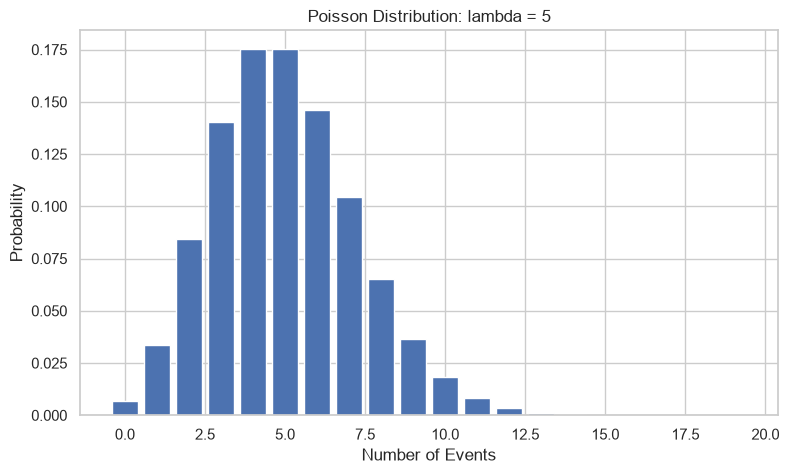

Expected value: 5
Variance: 5


In [15]:
lam = 5

x = np.arange(0, 20)
y = poisson.pmf(x, mu=lam)

plt.figure(figsize=(9, 5))
plt.bar(x, y)
plt.title("Poisson Distribution: lambda = 5")
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.show()

print("Expected value:", lam)
print("Variance:", lam)

# 18. Poisson probability questions

Example:

If average support tickets per hour is 4:

> What is probability of exactly 2 tickets in one hour?

```python
poisson.pmf(2, mu=4)
```

> What is probability of 7 or more tickets?

```python
1 - poisson.cdf(6, mu=4)
```

In [21]:
lam = 4

prob_exact_2 = poisson.pmf(3, mu=lam)
prob_7_or_more = 1 - poisson.cdf(7, mu=lam)

print("P(exactly 2 tickets):", round(prob_exact_2, 4))
print("P(7 or more tickets):", round(prob_7_or_more, 4))

P(exactly 2 tickets): 0.1954
P(7 or more tickets): 0.0511


# 19. Interactive Poisson distribution

Change lambda.

Notice:

- higher lambda shifts the distribution right
- mean and variance are both lambda

In [22]:
def plot_poisson(lam=5):
    x = np.arange(0, max(20, int(lam * 4)))
    y = poisson.pmf(x, mu=lam)

    plt.figure(figsize=(9, 5))
    plt.bar(x, y)
    plt.title(f"Poisson Distribution | lambda={lam:.1f}")
    plt.xlabel("Number of Events")
    plt.ylabel("Probability")
    plt.show()

    print("Mean:", lam)
    print("Variance:", lam)

if WIDGETS_AVAILABLE:
    interact(
        plot_poisson,
        lam=widgets.FloatSlider(value=5, min=0.5, max=20, step=0.5)
    )
else:
    plot_poisson(5)

interactive(children=(FloatSlider(value=5.0, description='lam', max=20.0, min=0.5, step=0.5), Output()), _dom_…

# 20. Exponential distribution

Exponential distribution models waiting time until the next event.

Examples:

- time until next website visitor
- time until next support ticket
- time until machine failure
- time until next fraud attempt
- time between customer arrivals

If events follow a Poisson process, waiting times often follow an Exponential distribution.

Parameter:

```text
scale = average waiting time
```

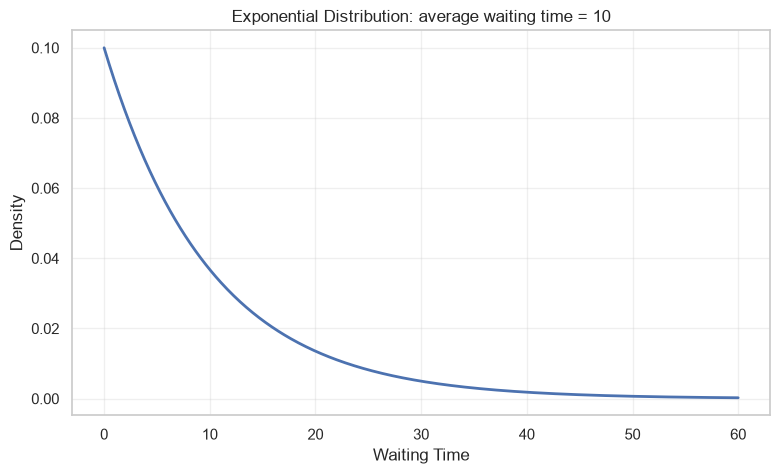

In [23]:
scale = 10  # average waiting time

x = np.linspace(0, 60, 500)
y = expon.pdf(x, scale=scale)

plt.figure(figsize=(9, 5))
plt.plot(x, y, linewidth=2)
plt.title("Exponential Distribution: average waiting time = 10")
plt.xlabel("Waiting Time")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

# 21. Exponential probability questions

Example:

If average waiting time is 10 minutes:

> Probability next customer arrives within 5 minutes?

```python
expon.cdf(5, scale=10)
```

> Probability we wait more than 20 minutes?

```python
1 - expon.cdf(20, scale=10)
```

In [19]:
scale = 10

prob_within_5 = expon.cdf(5, scale=scale)
prob_more_than_20 = 1 - expon.cdf(20, scale=scale)

print("P(waiting time <= 5):", round(prob_within_5, 4))
print("P(waiting time > 20):", round(prob_more_than_20, 4))

P(waiting time <= 5): 0.3935
P(waiting time > 20): 0.1353


# 22. Interactive Exponential distribution

Change average waiting time.

Higher scale means longer waiting time and slower decay.

In [24]:
def plot_exponential(scale=10):
    x = np.linspace(0, scale * 6, 500)
    y = expon.pdf(x, scale=scale)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, linewidth=2)
    plt.title(f"Exponential Distribution | Average waiting time = {scale:.1f}")
    plt.xlabel("Waiting Time")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    plt.show()

if WIDGETS_AVAILABLE:
    interact(
        plot_exponential,
        scale=widgets.FloatSlider(value=10, min=1, max=50, step=1)
    )
else:
    plot_exponential(10)

interactive(children=(FloatSlider(value=10.0, description='scale', max=50.0, min=1.0, step=1.0), Output()), _d…

# 23. Log-normal distribution

A variable is log-normal if its logarithm is normally distributed.

Log-normal distributions are common for:

- income
- prices
- spending
- transaction amounts
- file sizes
- time to complete tasks

Why?

Many real-world quantities are positive and right-skewed.

They cannot go below zero, but can have a long right tail.

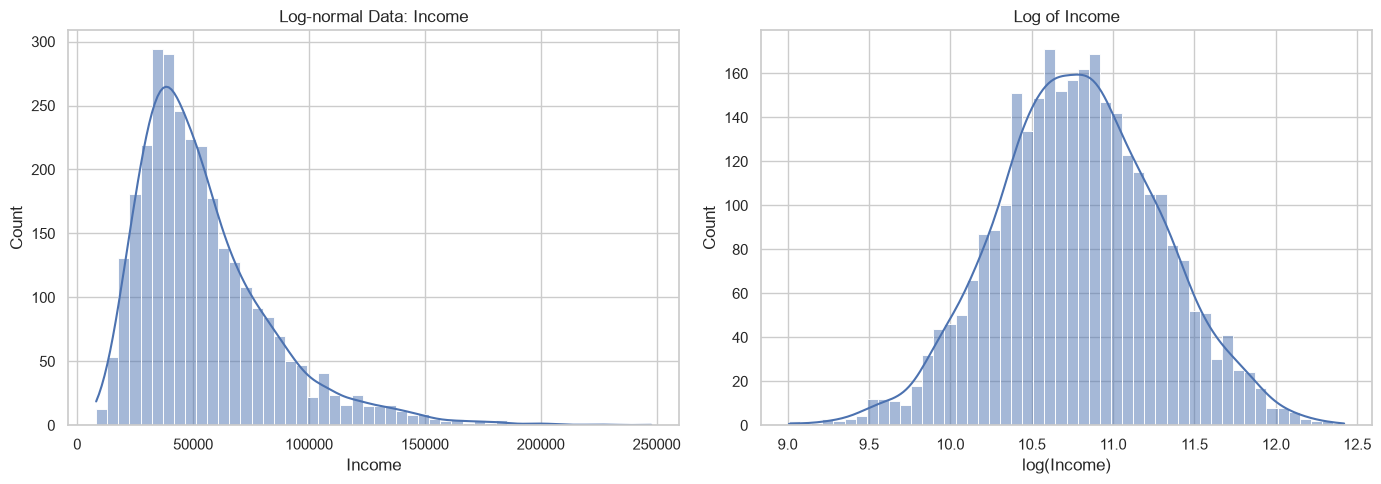

Income skew: 1.587
Log-income skew: 0.01


In [21]:
# Generate log-normal income-like data
income = np.random.lognormal(mean=10.8, sigma=0.5, size=3000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(income, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Log-normal Data: Income")
axes[0].set_xlabel("Income")

sns.histplot(np.log(income), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log of Income")
axes[1].set_xlabel("log(Income)")

plt.tight_layout()
plt.show()

print("Income skew:", pd.Series(income).skew().round(3))
print("Log-income skew:", pd.Series(np.log(income)).skew().round(3))

# 24. Why log transform helps ML

Right-skewed features can create problems for some models.

A log transform can:

- reduce skewness
- reduce outlier impact
- make patterns more linear
- stabilize variance

Common transform:

```python
np.log1p(x)
```

`log1p` means:

```text
log(1 + x)
```

It is safe when values include zero.

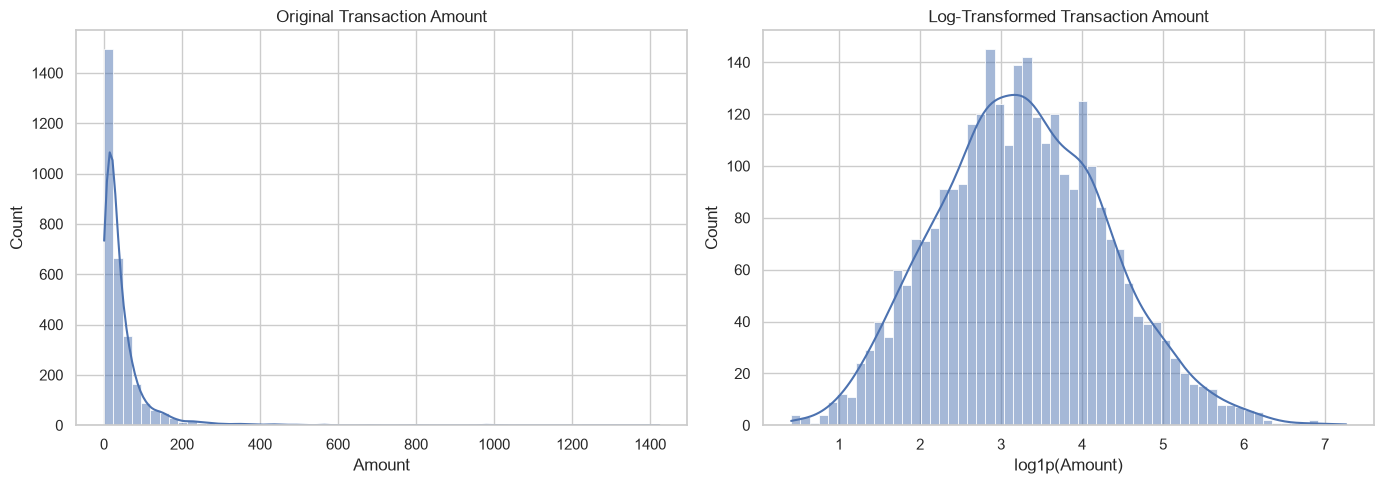

Original skew: 6.696
Log-transformed skew: 0.194


In [28]:
transaction_amount = np.random.lognormal(mean=3.2, sigma=1.1, size=3000)

transaction_log = np.log1p(transaction_amount)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(transaction_amount, bins=60, kde=True, ax=axes[0])
axes[0].set_title("Original Transaction Amount")
axes[0].set_xlabel("Amount")

sns.histplot(transaction_log, bins=60, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Transaction Amount")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()

print("Original skew:", pd.Series(transaction_amount).skew().round(3))
print("Log-transformed skew:", pd.Series(transaction_log).skew().round(3))

# 25. Compare common distributions visually

Now we compare samples from different distributions.

This helps you recognize shapes.

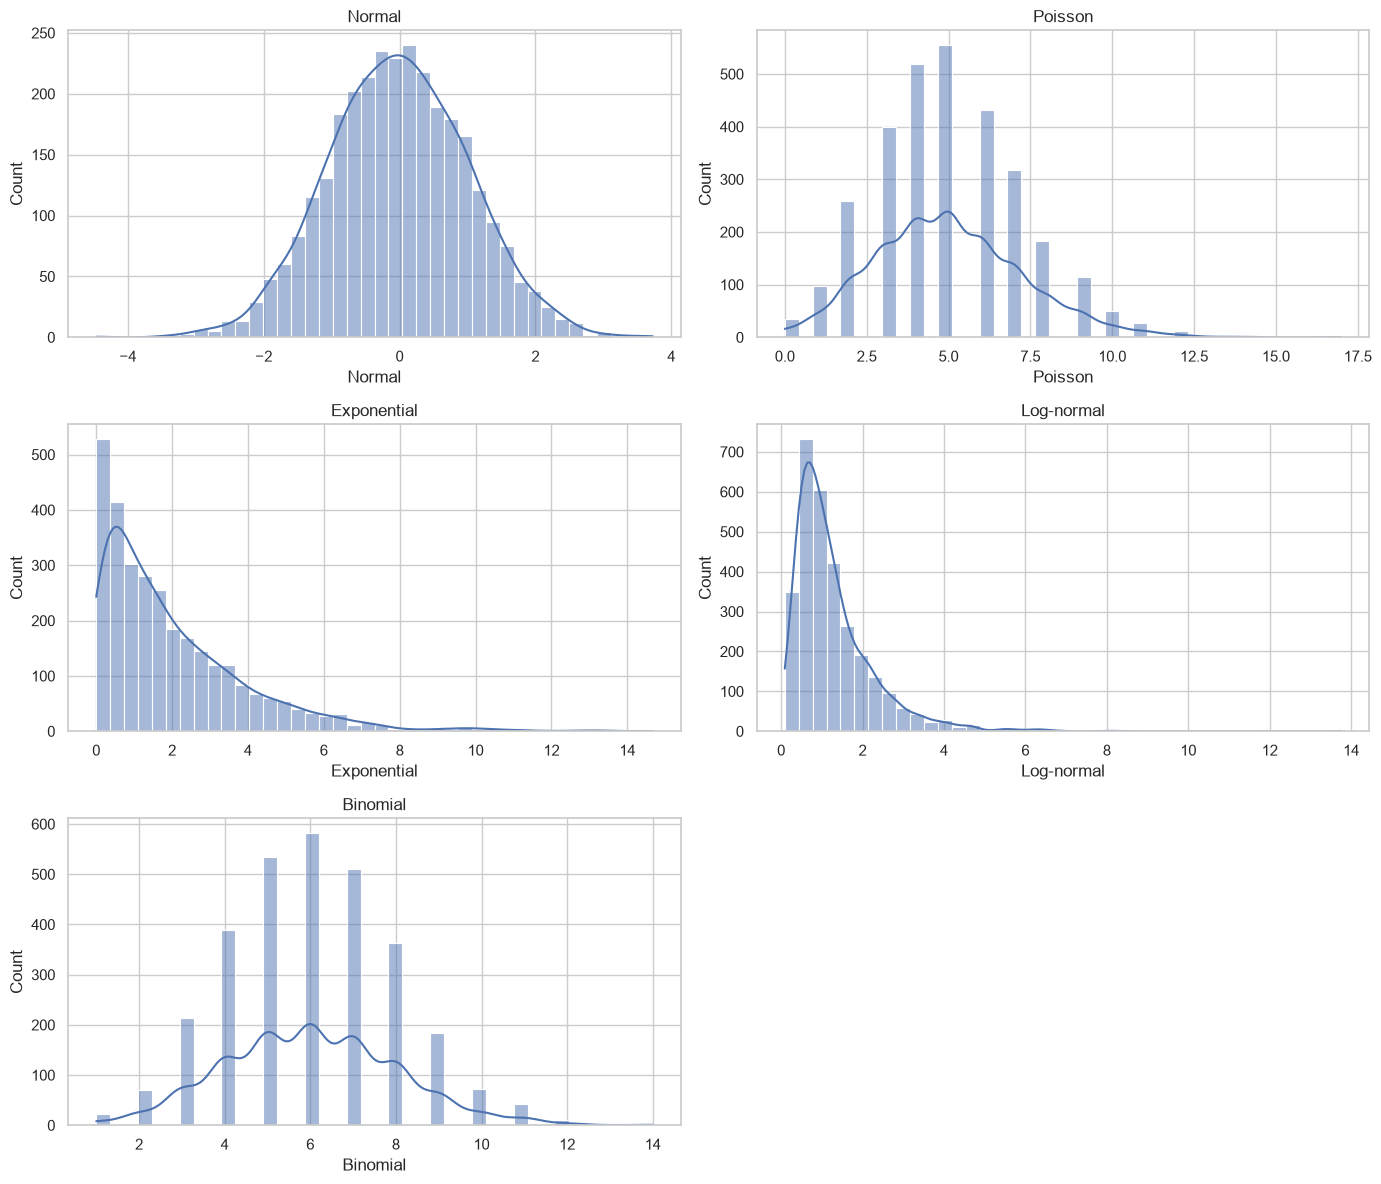

In [29]:
n = 3000

samples = pd.DataFrame({
    "Normal": np.random.normal(0, 1, n),
    "Poisson": np.random.poisson(5, n),
    "Exponential": np.random.exponential(2, n),
    "Log-normal": np.random.lognormal(0, 0.7, n),
    "Binomial": np.random.binomial(20, 0.3, n)
})

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes, samples.columns):
    sns.histplot(samples[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

# 26. Create a realistic ML dataset with different distributions

Now we create a customer dataset where each feature follows a different distribution.

This is closer to real-world ML data.

In [30]:
n = 2500

customer_df = pd.DataFrame({
    "churn": np.random.binomial(1,0.25, n),                       # Bernoulli
    "support_tickets": np.random.poisson(2, n),                    # Poisson
    "monthly_spend": np.random.lognormal(3.5, 0.6, n),             # Log-normal
    "age": np.random.normal(36, 10, n).clip(18, 75),               # Normal-like
    "time_until_next_purchase": np.random.exponential(20, n),      # Exponential
    "ad_clicks_out_of_20": np.random.binomial(20, 0.18, n)         # Binomial
})

# Make churn more realistic using feature effects
logit = (
    -2.4
    + customer_df["support_tickets"] * 0.30
    - customer_df["monthly_spend"] * 0.005
    + customer_df["time_until_next_purchase"] * 0.015
    - customer_df["ad_clicks_out_of_20"] * 0.08
)

prob = 1 / (1 + np.exp(-logit))
customer_df["churn"] = np.random.binomial(1, prob)

customer_df.head()

,churn,support_tickets,monthly_spend,age,time_until_next_purchase,ad_clicks_out_of_20
0,0,0,34.857225,29.826321,4.886042,2
1,0,1,20.150712,24.225598,19.103898,6
2,0,2,20.791417,55.068578,53.037992,3
3,0,1,29.325420,39.186232,27.961818,4
4,0,1,59.656255,46.668466,15.865499,3


# 27. Distribution profile

We inspect each feature and guess its distribution.

In [31]:
profile = pd.DataFrame({
    "mean": customer_df.mean(),
    "median": customer_df.median(),
    "std": customer_df.std(),
    "skew": customer_df.skew(),
    "min": customer_df.min(),
    "max": customer_df.max()
})

display(profile.round(3))

,mean,median,std,skew,min,max
churn,0.124,0.000,0.329,2.289,0.000,1.000
support_tickets,2.008,2.000,1.407,0.691,0.000,8.000
monthly_spend,39.950,33.777,25.439,1.868,3.568,207.445
age,36.194,35.996,9.606,0.185,18.000,73.162
time_until_next_purchase,19.553,13.401,20.217,2.323,0.003,234.827
ad_clicks_out_of_20,3.630,4.000,1.728,0.380,0.000,10.000


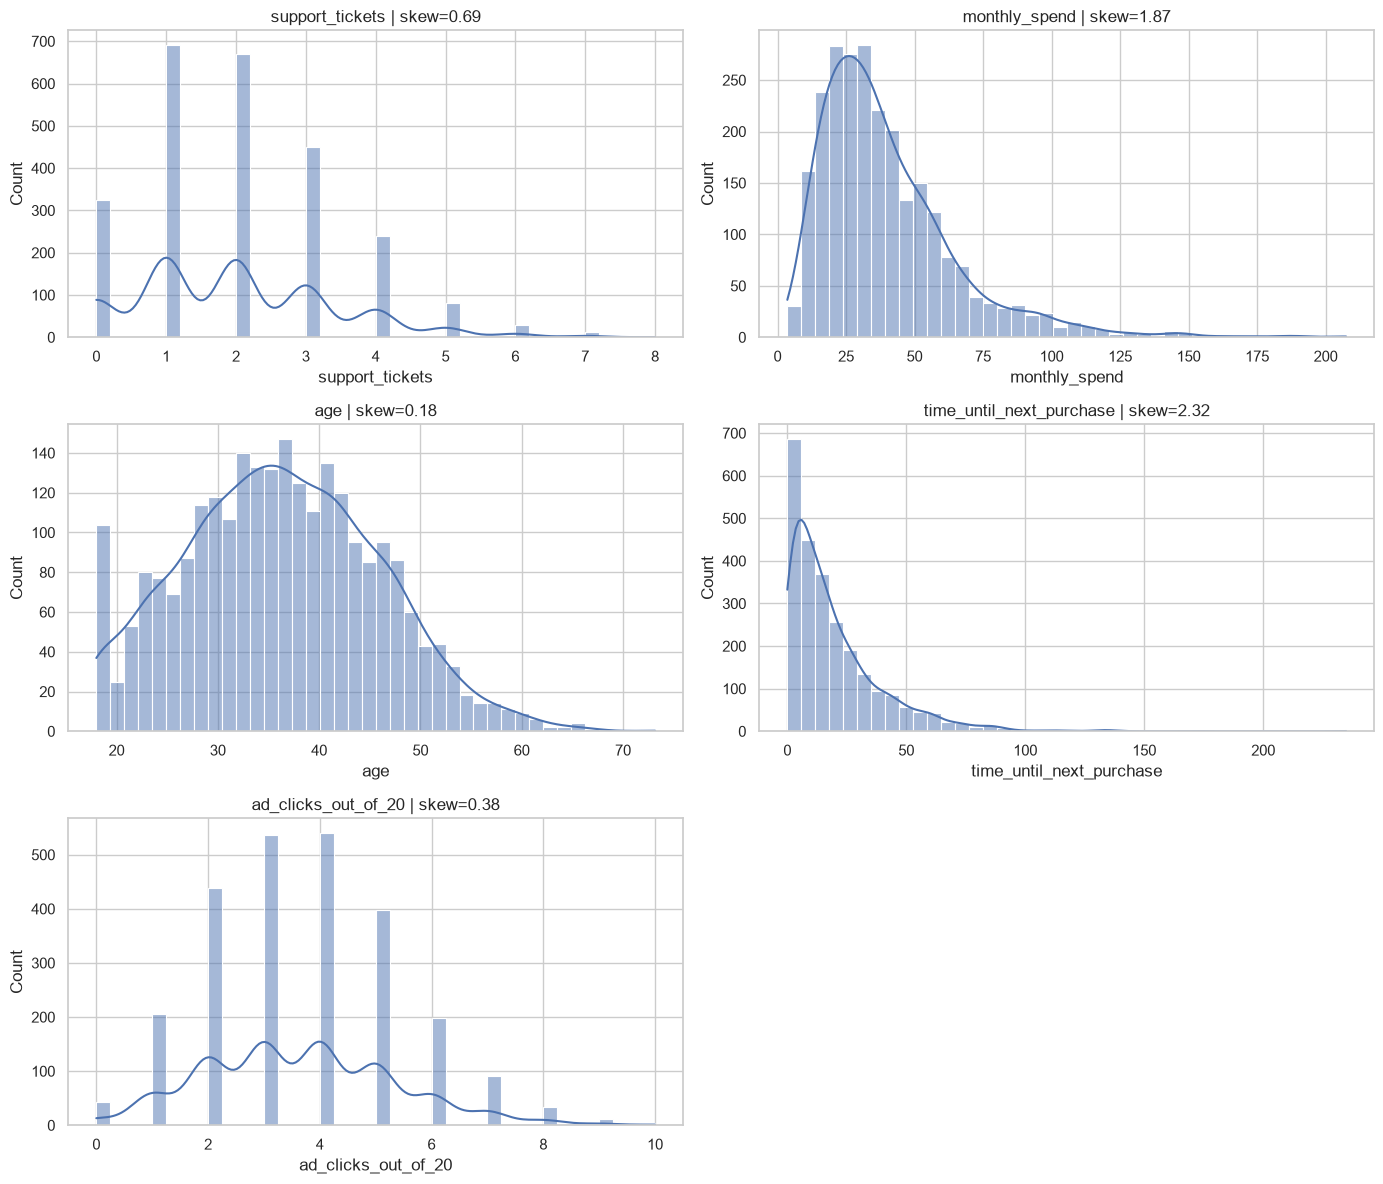

In [32]:
feature_cols = ["support_tickets", "monthly_spend", "age", "time_until_next_purchase", "ad_clicks_out_of_20"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.histplot(customer_df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"{col} | skew={customer_df[col].skew():.2f}")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

# 28. Q-Q plot for checking normality

A Q-Q plot compares data quantiles with theoretical normal quantiles.

If points roughly follow a straight line, the data is close to normal.

This is useful for checking model assumptions and transformations.

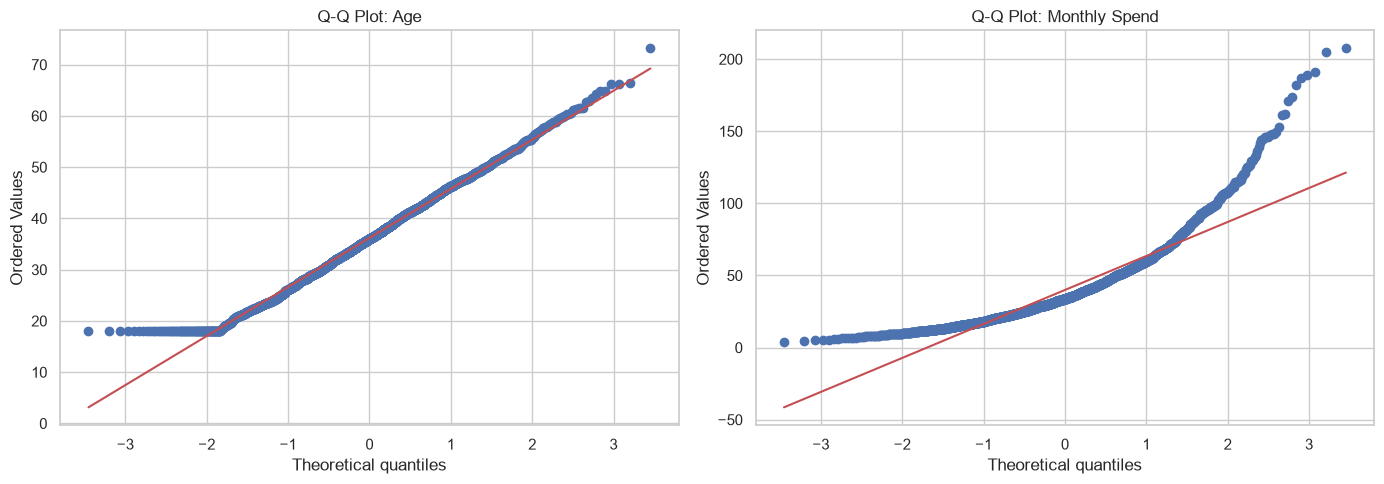

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(customer_df["age"], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Age")

stats.probplot(customer_df["monthly_spend"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Monthly Spend")

plt.tight_layout()
plt.show()

# 29. Log transform and Q-Q plot

Monthly spend is right-skewed.

After log transform, it should look more normal.

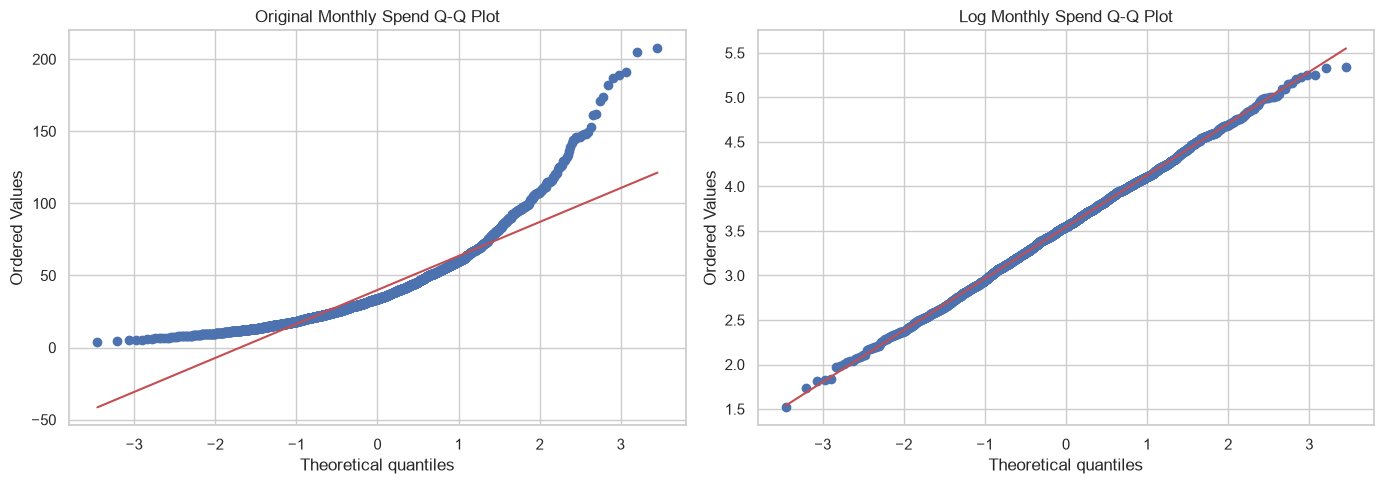

Original skew: 1.868
Log skew: -0.026


In [34]:
customer_df["log_monthly_spend"] = np.log1p(customer_df["monthly_spend"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(customer_df["monthly_spend"], dist="norm", plot=axes[0])
axes[0].set_title("Original Monthly Spend Q-Q Plot")

stats.probplot(customer_df["log_monthly_spend"], dist="norm", plot=axes[1])
axes[1].set_title("Log Monthly Spend Q-Q Plot")

plt.tight_layout()
plt.show()

print("Original skew:", customer_df["monthly_spend"].skew().round(3))
print("Log skew:", customer_df["log_monthly_spend"].skew().round(3))

# 30. Distribution and outliers

Different distributions have different outlier behavior.

For normal data:

- z-score can work well

For skewed data:

- IQR or log transform may be better
- z-score may flag too many high-tail values

In [35]:
def compare_outlier_methods(data, column):
    x = data[column]

    # z-score outliers
    z = (x - x.mean()) / x.std()
    z_outliers = np.abs(z) > 3

    # IQR outliers
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers = (x < lower) | (x > upper)

    return {
        "column": column,
        "z_outlier_count": int(z_outliers.sum()),
        "iqr_outlier_count": int(iqr_outliers.sum()),
        "skew": x.skew()
    }

outlier_comparison = pd.DataFrame([
    compare_outlier_methods(customer_df, "age"),
    compare_outlier_methods(customer_df, "monthly_spend"),
    compare_outlier_methods(customer_df, "time_until_next_purchase")
])

display(outlier_comparison.round(3))

,column,z_outlier_count,iqr_outlier_count,skew
0,age,4,8,0.185
1,monthly_spend,39,113,1.868
2,time_until_next_purchase,43,133,2.323


# 31. Distribution-aware preprocessing

A good ML engineer uses distributions to choose preprocessing.

| Distribution shape | Possible preprocessing |
|---|---|
| Normal-like | standardization |
| Right-skewed | log transform |
| Count data | maybe keep as count, maybe log1p |
| Binary data | keep 0/1 |
| Long-tail data | cap outliers or log transform |
| Very different scales | scale features |
| Heavy-tailed data | robust scaling or clipping |

Distributions guide preprocessing decisions.

In [36]:
preprocessed_df = customer_df.copy()

# Log transform skewed positive features
preprocessed_df["log_monthly_spend"] = np.log1p(preprocessed_df["monthly_spend"])
preprocessed_df["log_time_until_next_purchase"] = np.log1p(preprocessed_df["time_until_next_purchase"])

# Standardize selected features
scale_cols = ["age", "support_tickets", "ad_clicks_out_of_20", "log_monthly_spend", "log_time_until_next_purchase"]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(preprocessed_df[scale_cols])

scaled_df = pd.DataFrame(scaled_values, columns=[col + "_scaled" for col in scale_cols])

display(scaled_df.describe().round(3))

,age_scaled,support_tickets_scaled,ad_clicks_out_of_20_scaled,log_monthly_spend_scaled,log_time_until_next_purchase_scaled
count,2500.000,2500.000,2500.000,2500.000,2500.000
mean,0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.894,-1.428,-2.101,-3.493,-2.455
25%,-0.726,-0.717,-0.944,-0.679,-0.692
50%,-0.021,-0.006,0.214,0.006,0.108
75%,0.681,0.705,0.793,0.694,0.736
max,3.849,4.259,3.686,3.093,2.797


# 32. Train model with distribution-aware features

Now we compare:

1. Raw features
2. Distribution-aware transformed features

This shows how statistical understanding connects to ML.

In [38]:
raw_features = ["support_tickets", "monthly_spend", "age", "time_until_next_purchase", "ad_clicks_out_of_20"]
transformed_features = ["support_tickets", "log_monthly_spend", "age", "log_time_until_next_purchase", "ad_clicks_out_of_20"]

X_raw = customer_df[raw_features]
X_transformed = preprocessed_df[transformed_features]
y = customer_df["churn"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42, stratify=y
)

X_train_trans, X_test_trans, _, _ = train_test_split(
    X_transformed, y, test_size=0.25, random_state=42, stratify=y
)

raw_model = LogisticRegression(max_iter=1000)
raw_pipeline = StandardScaler()
X_train_raw_scaled = raw_pipeline.fit_transform(X_train_raw)
X_test_raw_scaled = raw_pipeline.transform(X_test_raw)

raw_model.fit(X_train_raw_scaled, y_train)
raw_pred = raw_model.predict(X_test_raw_scaled)

trans_model = LogisticRegression(max_iter=1000)
trans_pipeline = StandardScaler()
X_train_trans_scaled = trans_pipeline.fit_transform(X_train_trans)
X_test_trans_scaled = trans_pipeline.transform(X_test_trans)

trans_model.fit(X_train_trans_scaled, y_train)
trans_pred = trans_model.predict(X_test_trans_scaled)

print("Raw feature accuracy:", accuracy_score(y_test, raw_pred))#.round(3))
print("Transformed feature accuracy:", accuracy_score(y_test, trans_pred))#.round(3))

print("\nRaw features report:")
print(classification_report(y_test, raw_pred, zero_division=0))

print("\nTransformed features report:")
print(classification_report(y_test, trans_pred, zero_division=0))

Raw feature accuracy: 0.8784
Transformed feature accuracy: 0.8768

Raw features report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       548
           1       1.00      0.01      0.03        77

    accuracy                           0.88       625
   macro avg       0.94      0.51      0.48       625
weighted avg       0.89      0.88      0.82       625


Transformed features report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       548
           1       0.00      0.00      0.00        77

    accuracy                           0.88       625
   macro avg       0.44      0.50      0.47       625
weighted avg       0.77      0.88      0.82       625



# 33. Interactive distribution explorer

Choose a distribution and parameters.

This helps build intuition.

In [39]:
def distribution_explorer(distribution="Normal", param1=0.0, param2=1.0):
    plt.figure(figsize=(9, 5))

    if distribution == "Normal":
        mean = param1
        std = max(param2, 0.1)
        x = np.linspace(mean - 4 * std, mean + 4 * std, 500)
        y = norm.pdf(x, loc=mean, scale=std)
        plt.plot(x, y)
        plt.title(f"Normal(mean={mean:.1f}, std={std:.1f})")
        plt.xlabel("x")
        plt.ylabel("Density")

    elif distribution == "Poisson":
        lam = max(param1, 0.1)
        x = np.arange(0, max(20, int(lam * 4)))
        y = poisson.pmf(x, mu=lam)
        plt.bar(x, y)
        plt.title(f"Poisson(lambda={lam:.1f})")
        plt.xlabel("count")
        plt.ylabel("Probability")

    elif distribution == "Binomial":
        n = int(max(param1, 1))
        p = min(max(param2, 0.01), 0.99)
        x = np.arange(0, n + 1)
        y = binom.pmf(x, n=n, p=p)
        plt.bar(x, y)
        plt.title(f"Binomial(n={n}, p={p:.2f})")
        plt.xlabel("successes")
        plt.ylabel("Probability")

    elif distribution == "Exponential":
        scale = max(param1, 0.1)
        x = np.linspace(0, scale * 6, 500)
        y = expon.pdf(x, scale=scale)
        plt.plot(x, y)
        plt.title(f"Exponential(scale={scale:.1f})")
        plt.xlabel("waiting time")
        plt.ylabel("Density")

    elif distribution == "Log-normal":
        sigma = max(param2, 0.1)
        x = np.linspace(0.001, 20, 500)
        y = lognorm.pdf(x, s=sigma, scale=np.exp(param1))
        plt.plot(x, y)
        plt.title(f"Log-normal(meanlog={param1:.1f}, sigma={sigma:.1f})")
        plt.xlabel("x")
        plt.ylabel("Density")

    plt.grid(True, alpha=0.3)
    plt.show()

if WIDGETS_AVAILABLE:
    interact(
        distribution_explorer,
        distribution=widgets.Dropdown(
            options=["Normal", "Poisson", "Binomial", "Exponential", "Log-normal"],
            value="Normal"
        ),
        param1=widgets.FloatSlider(value=5.0, min=0.1, max=50.0, step=0.5, description="param1"),
        param2=widgets.FloatSlider(value=0.5, min=0.01, max=1.0, step=0.01, description="param2")
    )
else:
    distribution_explorer("Normal", 0.0, 1.0)

interactive(children=(Dropdown(description='distribution', options=('Normal', 'Poisson', 'Binomial', 'Exponent…

# 34. Distribution selection cheat sheet

| Data pattern | Likely distribution | Example |
|---|---|---|
| 0/1 outcome | Bernoulli | churn, fraud, click |
| Count of successes in fixed trials | Binomial | 7 clicks out of 20 ads |
| Bell-shaped continuous data | Normal | height, noise |
| Count per time/space interval | Poisson | calls per hour |
| Waiting time until next event | Exponential | time until next purchase |
| Positive right-skewed continuous data | Log-normal | income, spending |
| Heavy-tailed data | Log-normal / Pareto-like | wealth, file sizes |
| Model probability | Often beta-like | confidence scores |
| Prediction errors | Often normal-like but check | residuals |

# 35. Mini project — Distribution Analysis for ML Dataset

Your task is to analyze the customer dataset using distributions.

## Required sections

### Section 1 — Dataset overview
- shape
- columns
- target balance

### Section 2 — Distribution identification
For each feature, decide likely distribution:

- Bernoulli
- Binomial
- Normal
- Poisson
- Exponential
- Log-normal
- unknown/other

### Section 3 — Visualization
Create histograms for all features.

### Section 4 — Skewness
Calculate skewness and identify skewed features.

### Section 5 — Transformations
Apply log transform to right-skewed features.

### Section 6 — Outliers
Compare z-score and IQR outliers for at least 3 features.

### Section 7 — ML preprocessing plan
Write which features you would scale, transform, or keep as-is.

### Section 8 — Model experiment
Train a model using raw features and transformed features.

### Section 9 — Insights
Write at least 8 insights.

In [ ]:
# Mini project starter

print("Dataset shape:", customer_df.shape)

print("\nTarget balance:")
display(customer_df["churn"].value_counts(normalize=True).round(3))

print("\nDistribution profile:")
display(customer_df.describe().T.round(3))

print("\nSkewness:")
display(customer_df.skew().sort_values(ascending=False).round(3))

print("\nOutlier comparison:")
display(outlier_comparison.round(3))

# 36. Practice questions

Answer these in your own words.

1. What is a probability distribution?
2. What is the difference between discrete and continuous distributions?
3. What is PMF?
4. What is PDF?
5. What does Bernoulli distribution model?
6. What does Binomial distribution model?
7. What is the difference between Bernoulli and Binomial?
8. What are the parameters of Normal distribution?
9. What does standard deviation do to a normal curve?
10. What is the 68-95-99.7 rule?
11. What is a z-score?
12. What does Poisson distribution model?
13. Why is mean equal to variance in Poisson?
14. What does Exponential distribution model?
15. What is the connection between Poisson and Exponential?
16. What is a Log-normal distribution?
17. Why is income often log-normal?
18. Why does log transform help right-skewed data?
19. What is a Q-Q plot?
20. How do distributions guide preprocessing?
21. Why can z-score outlier detection fail on skewed data?
22. Why should we inspect distributions before ML modeling?

# 37. What we learned

In this notebook, we learned:

- Probability distributions describe how values occur
- Discrete variables use PMF
- Continuous variables use PDF
- Bernoulli models one binary trial
- Binomial models number of successes in multiple trials
- Normal distribution models bell-shaped continuous data
- Standard normal uses z-scores
- Poisson models event counts in fixed intervals
- Exponential models waiting times
- Log-normal models positive right-skewed data
- Real ML datasets contain many different distributions
- Q-Q plots help check normality
- Log transform can reduce skewness
- Distribution-aware preprocessing can improve modeling
- Outlier methods should depend on distribution shape

---

# Next Notebook

Notebook 4 will cover:

# Sampling, Confidence Intervals, and Hypothesis Testing

We will learn:

- sampling distribution
- standard error
- central limit theorem
- confidence intervals
- p-values
- hypothesis testing
- t-test
- chi-square test
- A/B testing
- statistical significance in ML experiments

# Cell 1 — Probability Distributions

# Probability Distributions

A probability distribution describes:

1. The possible values a random variable can take.
2. How likely those values are.

For example, when rolling a fair die:

[
X \in {1,2,3,4,5,6}
]

Every value has probability:

[
P(X=x)=\frac{1}{6}
]

A probability distribution helps us understand the expected pattern of random data.

---

# Cell 2 — Random Variable

## Random Variable

A random variable is a variable whose value depends on the result of a random experiment.

Examples:

* Number of heads in 10 coin flips
* Number of customers entering a shop
* Waiting time for the next phone call
* Height of a randomly selected person

A random variable is normally written as:

[
X
]

There are two main types:

* Discrete random variable
* Continuous random variable

---

# Cell 3 — Discrete vs Continuous Distributions

## Discrete Distribution

A discrete distribution contains countable values.

Examples:

[
0,1,2,3,\ldots
]

Real-life examples:

* Number of customers
* Number of heads
* Number of accidents
* Number of defective products

Discrete distributions use a **PMF**.

---

## Continuous Distribution

A continuous distribution can contain any value inside a range, including decimals.

Examples:

[
1.5,\ 1.52,\ 1.523,\ldots
]

Real-life examples:

* Height
* Weight
* Temperature
* Waiting time
* Product lifetime

Continuous distributions use a **PDF**.

---

# Cell 4 — PMF, PDF, CDF and RVS

## PMF

PMF means **Probability Mass Function**.

It gives the probability of one exact value in a discrete distribution.

[
P(X=x)
]

Example:

```python
binom.pmf(3, n=10, p=0.5)
```

This asks:

> What is the probability of exactly 3 successes?

---

## PDF

PDF means **Probability Density Function**.

It gives the density or curve height at a value in a continuous distribution.

```python
norm.pdf(0, loc=0, scale=1)
```

A PDF value is not the probability of one exact value.

For continuous data:

[
P(X=x)=0
]

Probability is found from the area under the PDF curve over a range.

---

## CDF

CDF means **Cumulative Distribution Function**.

It gives:

[
P(X\leq x)
]

Example:

```python
binom.cdf(3, n=10, p=0.5)
```

This calculates the probability of getting 3 or fewer successes.

---

## RVS

RVS means **Random Variates**.

It generates random observations from a distribution.

```python
binom.rvs(n=10, p=0.5, size=5)
```

This generates five random Binomial observations.

---

# Cell 5 — Bernoulli Distribution

## Bernoulli Distribution

The Bernoulli distribution models one experiment with only two possible outcomes.

The outcomes are normally represented as:

[
X=
\begin{cases}
1 & \text{success}\
0 & \text{failure}
\end{cases}
]

Examples:

* Head or tail
* Pass or fail
* Buy or not buy
* Spam or not spam
* Disease or no disease

The main parameter is:

[
p = \text{probability of success}
]

The probability of failure is:

[
1-p
]

Example:

```python
from scipy.stats import bernoulli

bernoulli.pmf(1, p=0.7)
```

This means:

> What is the probability of success when (p=0.7)?

The answer is:

[
0.7
]

### Mean

[
E(X)=p
]

### Variance

[
Var(X)=p(1-p)
]

### Main question

> Did one trial succeed or fail?

---

# Cell 6 — Binomial Distribution

## Binomial Distribution

The Binomial distribution models the number of successes in a fixed number of independent trials.

Each trial must:

1. Have two possible outcomes.
2. Have the same probability of success.
3. Be independent of the other trials.
4. Have a fixed number of trials.

The parameters are:

* (n): number of trials
* (p): probability of success

Example:

> A fair coin is flipped 10 times. What is the probability of getting exactly 6 heads?

```python
from scipy.stats import binom

binom.pmf(6, n=10, p=0.5)
```

This calculates:

[
P(X=6)
]

### Mean

[
E(X)=np
]

### Variance

[
Var(X)=np(1-p)
]

### Bernoulli vs Binomial

Bernoulli models one trial.

Binomial models several Bernoulli trials and counts the total successes.

### Main question

> How many successes occur in (n) trials?

---

# Cell 7 — Geometric Distribution

## Geometric Distribution

The Geometric distribution models the number of trials required to obtain the first success.

Example:

> How many coin flips are required before getting the first head?

Suppose:

[
p=0.5
]

The probability that the first success happens on trial 3 is:

```python
from scipy.stats import geom

geom.pmf(3, p=0.5)
```

For the first success to occur on trial 3, the results must be:

```text
Failure, Failure, Success
```

For a coin:

```text
Tail, Tail, Head
```

### Parameter

[
p = \text{probability of success}
]

### Mean

[
E(X)=\frac{1}{p}
]

### Main question

> On which trial will the first success occur?

---

# Cell 8 — Poisson Distribution

## Poisson Distribution

The Poisson distribution models the number of events occurring in a fixed interval.

The interval may represent:

* Time
* Distance
* Area
* Volume

Examples:

* Calls received in one hour
* Customers entering a shop in 10 minutes
* Accidents in one month
* Defects in one metre of fabric
* Website requests in one second

The main parameter is:

[
\lambda = \text{average number of events}
]

In SciPy, (\lambda) is written as `mu`.

Example:

> A shop receives an average of 4 customers every 10 minutes. What is the probability of exactly 3 customers?

```python
from scipy.stats import poisson

poisson.pmf(3, mu=4)
```

### Mean

[
E(X)=\lambda
]

### Variance

[
Var(X)=\lambda
]

The mean and variance are equal because both are controlled by the same Poisson parameter, (\lambda).

### Main question

> How many events occur in a fixed interval?

---

# Cell 9 — Discrete Uniform Distribution

## Discrete Uniform Distribution

A discrete uniform distribution has a fixed set of countable values, and every value has the same probability.

The best example is a fair die.

[
X\in{1,2,3,4,5,6}
]

Every outcome has probability:

[
P(X=x)=\frac{1}{6}
]

In SciPy, `randint` can represent a discrete uniform distribution.

```python
from scipy.stats import randint

randint.pmf(3, low=1, high=7)
```

Important:

* `low=1` is included.
* `high=7` is not included.
* Possible values are (1,2,3,4,5,6).

### Main question

> Which countable outcome occurs when all outcomes are equally likely?

---

# Cell 10 — Normal Distribution

## Normal Distribution

The Normal distribution is a continuous, symmetric, bell-shaped distribution.

Values near the mean are more common.

Values far from the mean are less common.

Examples that may be approximately normal:

* Human heights
* Measurement errors
* Some examination scores
* Some biological measurements

The Normal distribution has two parameters.

### Mean

[
\mu
]

The mean controls the centre of the curve.

### Standard deviation

[
\sigma
]

The standard deviation controls the spread.

A small standard deviation creates a narrow and tall curve.

A large standard deviation creates a wide and flat curve.

In SciPy:

```python
from scipy.stats import norm

norm.pdf(170, loc=165, scale=10)
```

Here:

* `loc=165` is the mean.
* `scale=10` is the standard deviation.
* `170` is the value where density is calculated.

### Main question

> How are continuous values distributed around an average?

---

# Cell 11 — The 68–95–99.7 Rule

## The 68–95–99.7 Rule

For a Normal distribution:

### One standard deviation

Approximately 68% of observations lie between:

[
\mu-\sigma
]

and

[
\mu+\sigma
]

### Two standard deviations

Approximately 95% of observations lie between:

[
\mu-2\sigma
]

and

[
\mu+2\sigma
]

### Three standard deviations

Approximately 99.7% of observations lie between:

[
\mu-3\sigma
]

and

[
\mu+3\sigma
]

This rule helps us understand how far normal observations are from the mean.

---

# Cell 12 — Continuous Uniform Distribution

## Continuous Uniform Distribution

A continuous uniform distribution contains every possible decimal value inside a range.

Every equal-width interval has the same probability.

Example:

> A bus may arrive at any time between 0 and 10 minutes.

The possible waiting times include:

[
0.5,\ 1.25,\ 3.786,\ 8.999,\ldots
]

The distribution has two boundaries:

* (a): minimum value
* (b): maximum value

The PDF density is constant:

[
f(x)=\frac{1}{b-a}
]

For a waiting time between 0 and 10:

[
f(x)=\frac{1}{10}=0.1
]

The probability of waiting between 2 and 4 minutes is:

[
P(2\leq X\leq4)
===============

# \frac{4-2}{10-0}

0.2
]

So the probability is 20%.

In SciPy:

```python
from scipy.stats import uniform

uniform.cdf(4, loc=0, scale=10) - uniform.cdf(2, loc=0, scale=10)
```

### Main question

> Which continuous value occurs when all equal-width intervals are equally likely?

---

# Cell 13 — Discrete Uniform vs Continuous Uniform

## Discrete Uniform vs Continuous Uniform

| Discrete Uniform                | Continuous Uniform                           |
| ------------------------------- | -------------------------------------------- |
| Contains countable values       | Contains all decimal values in a range       |
| Exact values have probabilities | Exact values have probability zero           |
| Uses PMF                        | Uses PDF                                     |
| Example: fair die               | Example: random waiting time                 |
| Every outcome is equally likely | Every equal-width interval is equally likely |

For a fair die:

[
P(X=3)=\frac{1}{6}
]

For continuous waiting time:

[
P(X=3)=0
]

However, a range such as (2\leq X\leq4) can have a positive probability.

---

# Cell 14 — Exponential Distribution

## Exponential Distribution

The Exponential distribution models the waiting time until the next event occurs.

Examples:

* Waiting time until the next customer
* Waiting time until the next phone call
* Time until the next website request
* Time until a machine fails

The main parameter is the event rate:

[
\lambda
]

If events occur at an average rate of 4 per hour:

[
\lambda=4
]

The average waiting time is:

[
\frac{1}{\lambda}
=================

\frac{1}{4}\text{ hour}
]

In SciPy, Exponential uses `scale`:

[
\text{scale}=\frac{1}{\lambda}
]

Example:

```python
from scipy.stats import expon

expon.pdf(0.5, scale=1/4)
```

### Mean

[
E(X)=\frac{1}{\lambda}
]

### Variance

[
Var(X)=\frac{1}{\lambda^2}
]

### Main question

> How long must we wait until the next event?

---

# Cell 15 — Poisson vs Exponential

## Poisson and Exponential Connection

Poisson and Exponential can describe the same event process from different viewpoints.

### Poisson distribution

Poisson counts the number of events.

Question:

> How many customers arrive in one hour?

### Exponential distribution

Exponential measures waiting time.

Question:

> How long until the next customer arrives?

Therefore:

* Poisson models event counts.
* Exponential models time between events.

---

# Cell 16 — Gamma Distribution

## Gamma Distribution

The Gamma distribution models the waiting time until several events occur.

The Exponential distribution models waiting time for one event.

The Gamma distribution can model waiting time for multiple events.

Example:

> How long will we wait until the fifth customer arrives?

The main parameters are:

* Shape (k): related to the number of events
* Scale (\theta): related to the event rate

In SciPy:

```python
from scipy.stats import gamma

gamma.pdf(3, a=5, scale=0.5)
```

Here:

* `a=5` is the shape.
* `scale=0.5` controls the waiting-time scale.

### Mean

[
E(X)=k\theta
]

### Variance

[
Var(X)=k\theta^2
]

### Exponential vs Gamma

* Exponential: waiting time for the next event.
* Gamma: waiting time for several events.

### Main question

> How long must we wait for multiple events?

---

# Cell 17 — Log-normal Distribution

## Log-normal Distribution

A variable follows a Log-normal distribution when its logarithm follows a Normal distribution.

[
\log(X)\sim N(\mu,\sigma^2)
]

Log-normal values are:

* Always positive
* Usually right-skewed
* Mostly small or medium
* Sometimes extremely large

Possible examples:

* Income
* House prices
* Company sizes
* Transaction values
* Product sales

In SciPy:

```python
from scipy.stats import lognorm

lognorm.pdf(10, s=1)
```

### Why can income look Log-normal?

Income is influenced by many factors that may multiply together:

* Education
* Experience
* Skills
* Industry
* Location
* Business opportunities

Most people have low or medium incomes, while a small number have extremely high incomes.

This creates a long right tail.

### Main question

> Does the variable contain positive values with a long right tail?

---

# Cell 18 — Why Log Transformation Helps

## Log Transformation

A log transformation reduces the difference between small and extremely large values.

Original values:

[
10,\ 100,\ 1000,\ 10000
]

Base-10 logarithms:

[
1,\ 2,\ 3,\ 4
]

A log transformation can:

* Reduce right skewness
* Reduce the effect of extreme values
* Stabilize variance
* Make relationships easier to model
* Make data closer to a Normal distribution

In Python:

```python
import numpy as np

data_log = np.log1p(data)
```

`log1p()` calculates:

[
\log(1+x)
]

It can safely handle zero values.

---

# Cell 19 — Beta Distribution

## Beta Distribution

The Beta distribution models uncertain probabilities.

Its values are always between:

[
0\leq X\leq1
]

Examples:

* Conversion rate
* Click-through rate
* Probability of success
* Percentage of customers who buy
* Probability that a model is correct

The Beta distribution has two parameters:

* (\alpha): evidence related to success
* (\beta): evidence related to failure

In SciPy:

```python
from scipy.stats import beta

beta.pdf(0.6, a=4, b=3)
```

The shape of the Beta distribution changes based on (\alpha) and (\beta).

* If successes are more common, the distribution moves toward 1.
* If failures are more common, the distribution moves toward 0.
* If both are similar, it may be centred around 0.5.

### Mean

[
E(X)=\frac{\alpha}{\alpha+\beta}
]

### Main question

> Which probability between 0 and 1 is most believable?

---

# Cell 20 — Weibull Distribution

## Weibull Distribution

The Weibull distribution commonly models product lifetimes and failure times.

Examples:

* Machine failure
* Electronic component lifetime
* Product reliability
* Material breaking time
* Medical survival time

The main parameters are:

* Shape parameter
* Scale parameter

In SciPy:

```python
from scipy.stats import weibull_min

weibull_min.pdf(5, c=2)
```

The shape parameter can represent different failure patterns.

### Shape less than 1

Failure risk decreases over time.

This can represent early manufacturing defects.

### Shape equal to 1

Failure risk remains constant.

This behaves like an Exponential distribution.

### Shape greater than 1

Failure risk increases over time.

This can represent ageing and wear.

### Main question

> When may a product or component fail?

---

# Cell 21 — Multinomial Distribution

## Multinomial Distribution

The Multinomial distribution is an extension of the Binomial distribution.

Binomial has two categories:

* Success
* Failure

Multinomial has more than two categories.

Example:

A customer chooses one colour:

* Red
* Blue
* Green

Suppose 10 customers make choices.

The possible result could be:

* 4 choose red
* 3 choose blue
* 3 choose green

In SciPy:

```python
from scipy.stats import multinomial

multinomial.pmf(
    [4, 3, 3],
    n=10,
    p=[0.4, 0.3, 0.3]
)
```

The category probabilities must add to 1:

[
0.4+0.3+0.3=1
]

### Parameters

* (n): total number of trials
* (p_1,p_2,\ldots,p_k): category probabilities
* Counts for each category

### Main question

> How are outcomes divided among several categories?

---

# Cell 22 — Distribution Comparison

## Quick Distribution Comparison

| Distribution       | Type       | Main purpose                        |
| ------------------ | ---------- | ----------------------------------- |
| Bernoulli          | Discrete   | One success or failure              |
| Binomial           | Discrete   | Number of successes in fixed trials |
| Geometric          | Discrete   | Trial number of first success       |
| Poisson            | Discrete   | Number of events in an interval     |
| Discrete Uniform   | Discrete   | Equally likely countable outcomes   |
| Normal             | Continuous | Values distributed around a mean    |
| Continuous Uniform | Continuous | Equal density over a range          |
| Exponential        | Continuous | Waiting time until next event       |
| Gamma              | Continuous | Waiting time until multiple events  |
| Log-normal         | Continuous | Positive right-skewed values        |
| Beta               | Continuous | Unknown probability between 0 and 1 |
| Weibull            | Continuous | Lifetime and failure time           |
| Multinomial        | Discrete   | Counts across multiple categories   |

---

# Cell 23 — How to Select a Distribution

## How to Select a Distribution

Ask the following questions.

### Is the variable discrete or continuous?

If values are counts such as (0,1,2,3), use a discrete distribution.

If values are measurements with decimals, use a continuous distribution.

### Does the experiment have one success/failure trial?

Use Bernoulli.

### Are we counting successes in fixed trials?

Use Binomial.

### Are we waiting for the first success?

Use Geometric.

### Are we counting events in a time or area?

Use Poisson.

### Are all countable outcomes equally likely?

Use Discrete Uniform.

### Are continuous values symmetric around a mean?

Use Normal.

### Are all equal-width intervals equally likely?

Use Continuous Uniform.

### Are we measuring time until the next event?

Use Exponential.

### Are we measuring time until several events?

Use Gamma.

### Is the data positive and strongly right-skewed?

Consider Log-normal.

### Are we modelling an unknown probability?

Use Beta.

### Are we modelling product lifetime or failure?

Use Weibull.

### Are there more than two outcome categories?

Use Multinomial.

---

# Cell 24 — Why Distributions Matter in Machine Learning

## Why Probability Distributions Matter in Machine Learning

Probability distributions help us:

* Understand the shape of data
* Detect skewness
* Detect unusual observations
* Select suitable transformations
* Select appropriate statistical tests
* Understand model errors
* Estimate uncertainty
* Generate simulated data
* Choose suitable machine-learning models

Examples:

* Right-skewed income may need a log transformation.
* Normally distributed features may work well with standardization.
* Count data may be modelled using Poisson regression.
* Outlier detection using z-scores works better for approximately normal data.
* Beta distributions can represent uncertain conversion rates.
* Binomial distributions can model successful conversions.

---

# Cell 25 — Final Summary

# Final Summary

A probability distribution tells us which values can occur and how likely different values or ranges are.

The most important ideas are:

* Bernoulli: one success or failure
* Binomial: number of successes
* Geometric: first success
* Poisson: event counts
* Normal: values around an average
* Uniform: equally likely outcomes or ranges
* Exponential: waiting time for one event
* Gamma: waiting time for several events
* Log-normal: positive right-skewed values
* Beta: uncertain probabilities
* Weibull: lifetimes and failures
* Multinomial: several outcome categories

For discrete distributions:

```python
.pmf()
.cdf()
.rvs()
```

For continuous distributions:

```python
.pdf()
.cdf()
.rvs()
```

Remember:

[
\text{PMF}=\text{probability of an exact discrete value}
]

[
\text{PDF}=\text{density of a continuous value}
]

[
\text{CDF}=P(X\leq x)
]
